In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [2]:
DATASET_PATH = Path(
    "/Users/bhavaykhatri/Desktop/msclap_2023/"
    "singBAP_dataset_clap-2023_0.5s.parquet"
)

OUTPUT_DIR = Path(
    "/Users/bhavaykhatri/Desktop/msclap_2023/"
    "clap_0.5s_lda"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TARGET_EXPERIENCE = [
    "intermediate",
    "professional",
]

TARGET_CLASSES = [
    "correct",
    "arched_back",
    "hunched_back",
    "sideways",
    "chest_breathing",
    "over_articulation",
    "under_articulation",
]

df = pd.read_parquet(DATASET_PATH)

df = df[
    df["experience"].isin(TARGET_EXPERIENCE)
    & df["condition"].isin(TARGET_CLASSES)
].copy()

df = df.reset_index(drop=True)

print("Filtered shape:", df.shape)

print(
    df["condition"].value_counts()
)

Filtered shape: (28418, 13)
condition
correct               5137
hunched_back          4540
sideways              4285
chest_breathing       4259
over_articulation     3454
under_articulation    3381
arched_back           3362
Name: count, dtype: int64


In [3]:
def decode_embedding(value):
    if isinstance(
        value,
        (bytes, bytearray, memoryview),
    ):
        return np.frombuffer(
            value,
            dtype=np.float32,
        ).copy()

    return np.asarray(
        value,
        dtype=np.float32,
    ).reshape(-1)


X = np.vstack(
    df["embedding"].map(
        decode_embedding
    )
).astype(np.float32)

y = df["condition"].astype(str).to_numpy()

valid_rows = np.isfinite(X).all(axis=1)

X = X[valid_rows]
y = y[valid_rows]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", np.unique(y))

X shape: (28418, 1024)
y shape: (28418,)
Classes: ['arched_back' 'chest_breathing' 'correct' 'hunched_back'
 'over_articulation' 'sideways' 'under_articulation']


In [4]:
lda = LinearDiscriminantAnalysis(
    n_components=3
)

X_lda = lda.fit_transform(
    X,
    y,
)

print("Original shape:", X.shape)
print("LDA shape:", X_lda.shape)

print(
    "Explained discriminant ratios:",
    lda.explained_variance_ratio_,
)

Original shape: (28418, 1024)
LDA shape: (28418, 3)
Explained discriminant ratios: [0.29363844 0.26956546 0.13267487]


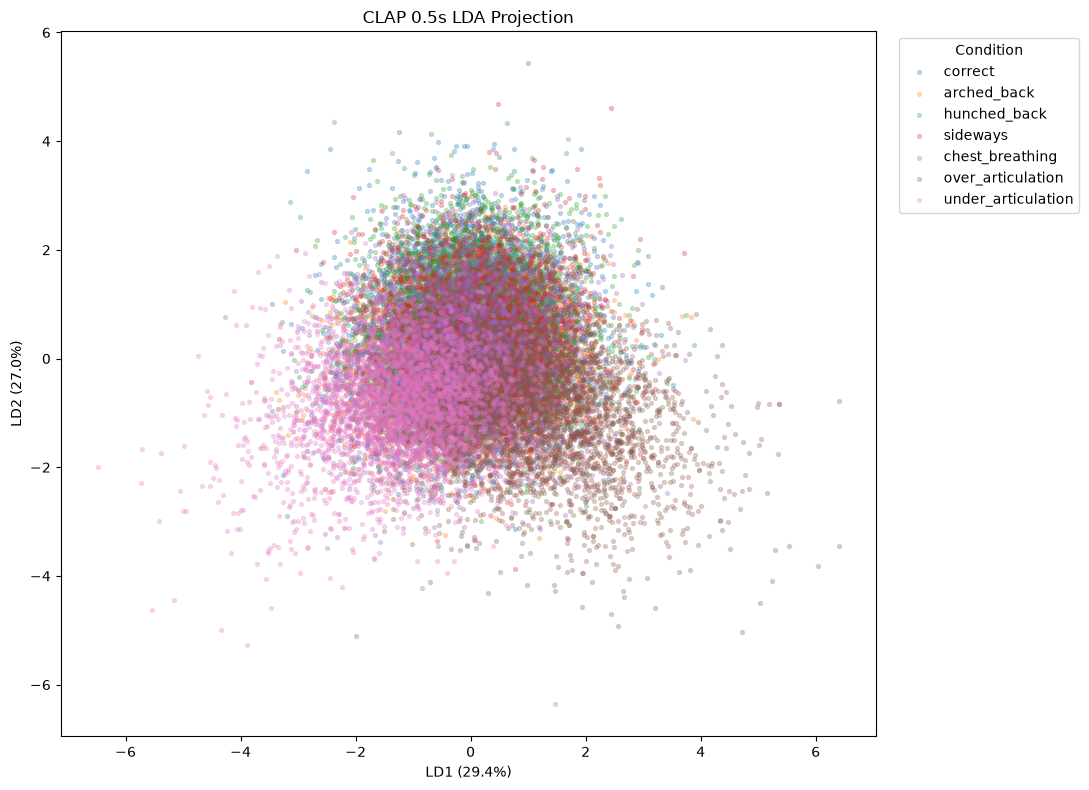

In [5]:
plt.figure(figsize=(11, 8))

for class_name in TARGET_CLASSES:
    class_mask = y == class_name

    plt.scatter(
        X_lda[class_mask, 0],
        X_lda[class_mask, 1],
        s=8,
        alpha=0.25,
        label=class_name,
    )

plt.xlabel(
    f"LD1 "
    f"({lda.explained_variance_ratio_[0] * 100:.1f}%)"
)

plt.ylabel(
    f"LD2 "
    f"({lda.explained_variance_ratio_[1] * 100:.1f}%)"
)

plt.title(
    "CLAP 0.5s LDA Projection"
)

plt.legend(
    title="Condition",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "clap_0.5s_lda_2d.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

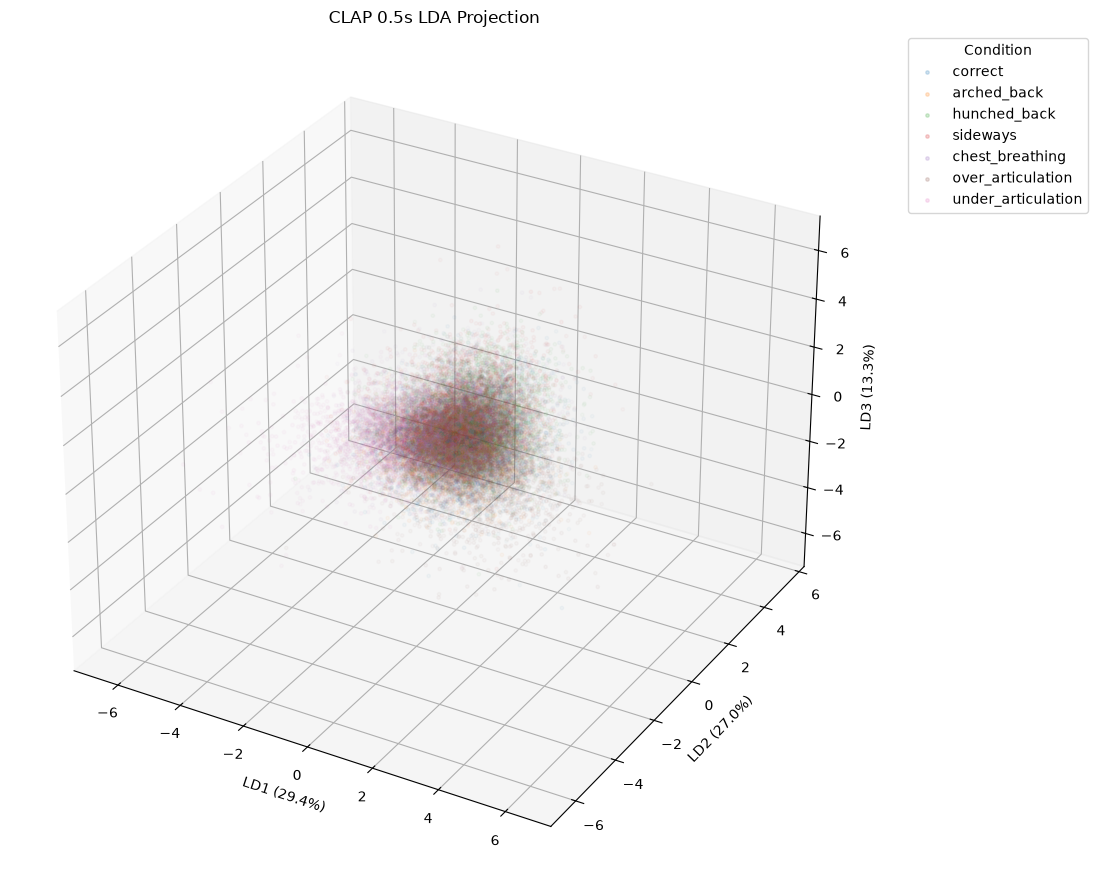

In [6]:
fig = plt.figure(
    figsize=(12, 9)
)

ax = fig.add_subplot(
    111,
    projection="3d",
)

for class_name in TARGET_CLASSES:
    class_mask = y == class_name

    ax.scatter(
        X_lda[class_mask, 0],
        X_lda[class_mask, 1],
        X_lda[class_mask, 2],
        s=6,
        alpha=0.20,
        label=class_name,
    )

ax.set_xlabel(
    f"LD1 "
    f"({lda.explained_variance_ratio_[0] * 100:.1f}%)"
)

ax.set_ylabel(
    f"LD2 "
    f"({lda.explained_variance_ratio_[1] * 100:.1f}%)"
)

ax.set_zlabel(
    f"LD3 "
    f"({lda.explained_variance_ratio_[2] * 100:.1f}%)"
)

ax.set_title(
    "CLAP 0.5s LDA Projection"
)

ax.legend(
    title="Condition",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "clap_0.5s_lda_3d.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [7]:
lda_results = pd.DataFrame({
    "LD1": X_lda[:, 0],
    "LD2": X_lda[:, 1],
    "LD3": X_lda[:, 2],
    "condition": y,
})

lda_results.to_csv(
    OUTPUT_DIR / "clap_0.5s_lda_coordinates.csv",
    index=False,
)